# J-lens vs logit lens on Qwen3.5-9B — scoring across languages

**Question.** `qwen35_9b_lens_summary.ipynb` scores both lenses with **English spellings only**,
and Qwen often reads concepts out in Chinese (`意大利` for *Italy*, `二十` for *20*), which counts
as a miss. If a token that *means* the annotated word in any language also counts, how do the
two lenses compare, and how much of the J-lens lead under English-only scoring was a
language artefact?

**Answer (this run).** **Yes, the J-lens lead from English-only scoring was mostly a language artefact.** Once
tokens that mean the word in any language count:

* **Pooled, the two lenses tie.** Intermediate hit@10 is 0.383 for the logit lens and 0.372 for
  the J-lens (J − logit −0.011 [−0.044, +0.021]). Under strict scoring it was 0.320 vs 0.359
  (+0.039 [+0.008, +0.070]). By AUC over k the logit lens is now slightly *ahead*
  (−0.027 [−0.049, −0.007]).
* **Translation helps the logit lens about 5× as much.** Its gain is +0.062 [+0.045, +0.081] against
  +0.013 [+0.005, +0.022] for the J-lens. Controls rise only +0.010 / +0.005, so the gain is the concept,
  not the larger accepted sets.
* **Per dataset**, under translated scoring:
  * multihop still leans J-lens (+0.077 [−0.024, +0.179]; AUC +0.061 [+0.022, +0.098]);
  * multilingual becomes a tie (+0.016 [−0.016, +0.047], was +0.085);
  * typo turns to the logit lens (−0.146 [−0.260, −0.021]).
* **Answer targets also tie** (+0.005 [−0.027, +0.036], was +0.032).
* **Answer accuracy barely moves** (multilingual 18 → 20 of 79, multihop 28 → 29 of 88). The model's
  first token is usually a fragment (`pe`, `2`), not a translation.
* **Most Chinese readouts are not the concept.** Of the logit lens's Chinese top-1 tokens, 67% are an
  annotated word on multilingual and 25% on order-ops, but 10% on multihop and 0% on poetry and
  association. Poetry and association stay near zero for both lenses, so they are not a translation
  artefact.

Same model, lens, prompts, readout positions and metrics as the summary notebook; only the
set of accepted tokens per word changes. **Nothing is fitted.**

## Method

**Two scoring protocols, one model, two passes.**

* **strict** — `jlens.strict_scoring.DecodedSpellings`, exactly as in the summary notebook: a
  token counts if it decodes to the word (as-is/lower/capitalised, optional leading space;
  order-ops adds digit/word and operation synonyms).
* **translated** — `jlens.translated_scoring.TranslatedSpellings`: strict spellings, plus
  tokens that **mean** the word according to a token → English glossary:
  * `意大利`, `イタリア`, ` Италия` for *Italy* (gloss = the word);
  * `二十`, `廿`, full-width `２０` for *20* (number word, NFKC folding);
  * for a label written in another language, tokens sharing the gloss of the label's own
    token: target `黄` → *yellow* → ` yellow`, `黄色`;
  * a small hand-written alias list for the Chinese operation words the glossary renders
    loosely (`除以` is glossed *divide by*, `减` *reduce*).

  Operation synonyms such as *product* or *times* are **not** translated, because their other
  senses (`产品` a product, `次数` a count) are not the operation. Matching is still on whole
  tokens only, with no prefixes and no multi-token words.

**Glossary.** `assets/qwen_gloss.json.gz`: 91,695 Qwen token IDs with an English gloss (62k
CJK, 14k Cyrillic, 6k Arabic, 6k Hangul, 4k Thai, …), plain-ASCII tokens not glossed. It was
shipped as display metadata and its provenance is unverified, so §5 lists the translated
tokens that actually produced hits, for inspection. Placeholder glosses (`fragment`) never
match.

**Fairness checks.**

* **Controls** (another item's intermediates) are expanded the same way, so the chance level
  of the larger accepted sets is measured, not assumed.
* **Prompt guard.** A translation can be the prompt's own word (prompt `"香蕉"的颜色是"`
  contains `香蕉` = *banana*). §4 repeats the benchmark without words whose accepted tokens
  occur in the prompt.
* Translated accepted sets contain the strict ones, so per word the translated rank is never
  worse. The comparison is therefore on the **same items and words**, and the change is the
  translation gain.

**Metrics** (as in the summary notebook). Readout at the last prompt token (poetry: last
newline). A supported word hits if its best rank over the **inner blocks** 0–30 is ≤ K = 10.
Item-averaged; AUC over k ∈ {1, 2, 5, 10, 20, 50, 100}; paired item bootstrap 95% CIs.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_DIR = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "translated_scoring.py").is_file()),
    None,
)
if REPO_DIR is None:
    raise RuntimeError("Open this notebook from a checkout of the repository.")
sys.path.insert(0, str(REPO_DIR))

import gzip
import hashlib
import json
import pickle
import re
import subprocess
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers
from huggingface_hub import hf_hub_download
from IPython.display import display
from transformers import AutoModelForCausalLM, AutoTokenizer

import jlens
from jlens.batched_evaluation import evaluate_paired_batched
from jlens.evaluation import DATASETS, load_eval
from jlens.reference_plots import SWEEP_KS
from jlens.strict_scoring import DecodedSpellings, ExplicitPromptModel
from jlens.summaries import answer_counts
from jlens.translated_scoring import TranslatedSpellings

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 120)
LENSES = ["logit lens", "J-lens"]
SCHEMES = ["strict", "translated"]
COLORS = {"J-lens": "tab:blue", "logit lens": "tab:purple"}

In [2]:
MODEL_ID = os.environ.get("JLENS_MODEL_ID", "Qwen/Qwen3.5-9B")
MODEL_REVISION = None  # None = the snapshot already in HF_HOME
LENS_REPO, LENS_FILE = "bcywinski/jacobian-lens-qwen3.5-9b", "lens_n1000.pt"
GLOSS_PATH = REPO_DIR / "assets" / "qwen_gloss.json.gz"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = getattr(torch, os.environ.get("JLENS_DTYPE", "bfloat16"))  # as in the summary notebook
BOS_POLICY = "none"  # Qwen has no BOS token
K = 10
KS = SWEEP_KS  # (1, 2, 5, 10, 20, 50, 100)
N_BOOT = 2000
BATCH_OPTIONS = dict(
    batch_size=8, max_batch_tokens=2048, max_seq_len=512,
    position_chunk_size=8, rank_chunk_size=8, batching="auto",
)
# Chinese operation words that the glossary renders loosely (除以 -> "divide by", 减 -> "reduce").
ALIASES = {
    "addition": ["加", "加法", "加上"],
    "subtraction": ["减", "减法", "减去"],
    "multiplication": ["乘", "乘法", "乘以"],
    "division": ["除", "除法", "除以"],
    "squared": ["平方"],
}
SLUG = MODEL_ID.split("/")[-1].lower()
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", REPO_DIR / "runs" / f"{SLUG}-lens-translated"))
RUN_DIR.mkdir(parents=True, exist_ok=True)
REFRESH = False  # True recomputes every cached step below

### Load the model, the pretrained lens and the glossary

In [3]:
def file_sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, revision=MODEL_REVISION)
hf_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, revision=MODEL_REVISION, dtype=DTYPE)
hf_model = hf_model.to(DEVICE).eval()
assert hf_model.dtype == DTYPE, f"loaded {hf_model.dtype}, requested {DTYPE}"
adapter = jlens.from_hf(hf_model, tokenizer, compile=False, force_bos=False)
model = ExplicitPromptModel(adapter, bos_policy=BOS_POLICY)

lens_path = hf_hub_download(LENS_REPO, LENS_FILE)
lens_sha256 = file_sha256(lens_path)
stored = jlens.JacobianLens.load(lens_path)
INNER = list(range(model.n_layers - 1))
assert stored.d_model == model.d_model, "lens/model residual widths differ"
assert set(INNER) <= set(stored.source_layers), "lens is missing inner blocks"
for layer in INNER:
    matrix = stored.jacobians[layer]
    assert matrix.shape == (model.d_model, model.d_model) and torch.isfinite(matrix).all(), layer
lens = jlens.JacobianLens(
    {layer: stored.jacobians[layer] for layer in INNER},
    n_prompts=stored.n_prompts, d_model=stored.d_model,
)
del stored, matrix

VOCAB_SIZE = hf_model.get_output_embeddings().weight.shape[0]
with gzip.open(GLOSS_PATH, "rt", encoding="utf-8") as handle:
    GLOSS = {int(key): value for key, value in json.load(handle).items()}
spellings = {
    "strict": DecodedSpellings(tokenizer, vocab_size=VOCAB_SIZE),
    "translated": TranslatedSpellings(tokenizer, vocab_size=VOCAB_SIZE, glossary=GLOSS, aliases=ALIASES),
}
translated = spellings["translated"]
print(adapter, "|", lens)
print(f"glossary: {len(GLOSS)} entries, {len(translated.glossary)} usable on this vocabulary")

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

HFLensModel(Qwen3_5ForCausalLM, n_layers=32, d_model=4096) | JacobianLens(d_model=4096, n_prompts=1000, source_layers=[0..30] (31 layers))
glossary: 91695 entries, 91452 usable on this vocabulary


In [4]:
def fingerprint(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, ensure_ascii=False, default=str).encode()).hexdigest()


def source_hashes(*modules):
    """Hash jlens sources so local edits invalidate the caches."""
    return {name: file_sha256(REPO_DIR / "jlens" / f"{name}.py") for name in modules}


try:
    repo_commit = subprocess.check_output(["git", "-C", str(REPO_DIR), "rev-parse", "HEAD"], text=True).strip()
except (OSError, subprocess.CalledProcessError):
    repo_commit = None

# Recorded with the results, per AGENTS.md's Experiment Configuration.
RUN_INFO = {
    "model_id": MODEL_ID, "model_commit": getattr(hf_model.config, "_commit_hash", None),
    "dtype": str(hf_model.dtype), "device": DEVICE,
    "gpu": torch.cuda.get_device_name() if DEVICE == "cuda" else None,
    "n_layers": model.n_layers, "d_model": model.d_model, "vocab_size": VOCAB_SIZE,
    "lens": f"{LENS_REPO}/{LENS_FILE}", "lens_sha256": lens_sha256, "lens_n_prompts": lens.n_prompts,
    "lens_corpus": "Salesforce/wikitext wikitext-103-raw-v1 (train), 1000 x 128 tokens",
    "prompt_format": "raw text, whitespace preserved, no chat template, no BOS",
    "glossary": str(GLOSS_PATH.relative_to(REPO_DIR)), "glossary_sha256": file_sha256(GLOSS_PATH),
    "aliases": ALIASES, "batch": BATCH_OPTIONS,
    "torch": torch.__version__, "transformers": transformers.__version__, "repo_commit": repo_commit,
    "source": source_hashes("hf", "readout", "strict_scoring", "translated_scoring", "lens", "hooks",
                            "batched_evaluation", "evaluation"),
}
(RUN_DIR / "run_info.json").write_text(json.dumps(RUN_INFO, indent=1, ensure_ascii=False))
CACHE_KEY = {k: v for k, v in RUN_INFO.items() if k not in {"gpu", "repo_commit"}}


def cached(name, settings, compute):
    """Pickle `compute()` under RUN_DIR, keyed by the run configuration and `settings`."""
    path = RUN_DIR / f"{name}-{fingerprint([CACHE_KEY, settings])[:16]}.pkl"
    if path.is_file() and not REFRESH:
        print(f"cache hit: {path.name}")
        return pd.read_pickle(path)
    value = compute()
    fd, tmp = tempfile.mkstemp(dir=RUN_DIR, suffix=".tmp")
    with os.fdopen(fd, "wb") as handle:
        pickle.dump(value, handle)
    Path(tmp).replace(path)
    print(f"cache saved: {path.name}")
    return value


RUN_INFO

{'model_id': 'Qwen/Qwen3.5-9B',
 'model_commit': None,
 'dtype': 'torch.bfloat16',
 'device': 'cuda',
 'gpu': 'NVIDIA RTX A6000',
 'n_layers': 32,
 'd_model': 4096,
 'vocab_size': 248320,
 'lens': 'bcywinski/jacobian-lens-qwen3.5-9b/lens_n1000.pt',
 'lens_sha256': '25f7c003432b44f01b94a45a32322a4994186aad9110060a463392806a6525ba',
 'lens_n_prompts': 1000,
 'lens_corpus': 'Salesforce/wikitext wikitext-103-raw-v1 (train), 1000 x 128 tokens',
 'prompt_format': 'raw text, whitespace preserved, no chat template, no BOS',
 'glossary': 'assets/qwen_gloss.json.gz',
 'glossary_sha256': '6292605a41600960519be0f5638c62feaf3178a295e12d49001e0dad1333fa07',
 'aliases': {'addition': ['加', '加法', '加上'],
  'subtraction': ['减', '减法', '减去'],
  'multiplication': ['乘', '乘法', '乘以'],
  'division': ['除', '除法', '除以'],
  'squared': ['平方']},
 'batch': {'batch_size': 8,
  'max_batch_tokens': 2048,
  'max_seq_len': 512,
  'position_chunk_size': 8,
  'rank_chunk_size': 8,
  'batching': 'auto'},
 'torch': '2.12.0+cu1

## 1. What the translated protocol accepts

Accepted tokens per word, verbatim with their glosses, for a few labels, and how many
annotated words have at least one accepted token under each protocol.

In [5]:
evals = {name: load_eval(str(REPO_DIR), name) for name in DATASETS}


def show_token(token_id):
    text = tokenizer.decode([token_id])
    gloss = translated.glossary.get(token_id)
    return f"{text!r} ({gloss})" if gloss else repr(text)


examples = [("Italy", False), ("death", False), ("dawn", False), ("small", False), ("20", True),
            ("multiplication", True), ("黄", False), ("Tuesday", False)]
display(pd.DataFrame([
    {"word": word, "strict": len(spellings["strict"](word, expand)),
     "translated": len(translated(word, expand)),
     "examples of added tokens": ", ".join(show_token(t) for t in sorted(translated.translated(word, expand))[:10])}
    for word, expand in examples
]).set_index("word"))

label_rows = [
    {"dataset": dataset, "kind": kind, "word": word,
     **{scheme: bool(spellings[scheme](word, dataset == "order-ops")) for scheme in SCHEMES},
     "n_translated": len(translated.translated(word, dataset == "order-ops"))}
    for dataset in DATASETS for item in evals[dataset]
    for kind, word in [*(("intermediate", w) for w in item["intermediates"]),
                       *([("target", item["target"])] if item.get("target") else [])]
]
labels = pd.DataFrame(label_rows)
display(labels.groupby(["dataset", "kind"]).agg(
    annotated=("word", "size"), strict=("strict", "sum"), translated=("translated", "sum"),
    median_added_tokens=("n_translated", "median"),
))

,strict,translated,examples of added tokens
word,,,
Italy,2,16,"'意大利' (italy), '義大利' (italy), ' Ита' (italy), 'ิตาลี' (italy), 'يطاليا' (italy), ' الإيط' (italy), ' 이탈리아' (italy), ..."
death,4,21,"'死' (death), '死亡' (death), '去世' (death), '的死' (death), ' смер' (death), ' موت' (death), 'θαν' (death), ' tử' (death)..."
dawn,2,16,"'晓' (dawn), '旦' (dawn), '曙' (dawn), '曉' (dawn), '昕' (dawn), '黎明' (dawn), '晨曦' (dawn), '天亮' (dawn), 'зора' (dawn), 'ร..."
small,4,70,"'소' (small), ' SMALL', '작' (small), ' 작' (small), '小' (small), '的小' (small), '小的' (small), '芮' (small), '小型' (small)..."
20,4,11,"'２０', '二十' (twenty), '廿' (twenty), '二零' (twenty), '第二十' (twenty), 'ยี' (twenty), ' العشرين' (twenty)"
multiplication,17,26,"' PRODUCT', 'PRODUCT', '\tproduct', ' TIMES', '乘' (multiply), '乘法' (multiplication), '乘以' (multiply by), '＊', ' ＊'"
黄,1,15,"' yellow', ' Yellow', 'yellow', 'Yellow', ' YELLOW', 'YELLOW', '黃' (yellow), '黄色' (yellow), '黄色的' (yellow), '黄的' (ye..."
Tuesday,2,6,"'周二' (tuesday), '星期二' (tuesday), ' الثلاثاء' (tuesday), ' вторник' (tuesday)"


annotated  strict  translated  median_added_tokens
dataset      kind                                                            
association  intermediate        102     102         102                  6.0
multihop     intermediate        103      94          94                  8.0
             target               93      86          88                  2.0
multilingual intermediate        428     426         427                 18.0
             target              107      79          79                  0.0
order-ops    intermediate        110     109         110                  9.0
             target               55      53          55                 10.0
poetry       intermediate         98      98          98                 24.5
typo         intermediate         96      96          96                 31.0

## 2. Task passes and answer accuracy

One batched pass per protocol (the accepted sets differ, so do the stored ranks). With
translation, a model top-1 that **means** the target counts as correct: `二十` for *20*, ` yellow`
for target `黄`. Qwen's habit of starting an answer with a fragment (`pe` for *pequeño*, `2` for
*20*) is unchanged, so accuracy stays a lexical next-token measure.

In [6]:
runs = {
    scheme: cached(
        f"tasks-{scheme}", {"evals": evals, "batch": BATCH_OPTIONS, "scheme": scheme},
        lambda scheme=scheme: evaluate_paired_batched(
            model, lens, evals, spelling_lookup=spellings[scheme],
            preserve_prompt_whitespace=True, **BATCH_OPTIONS,
        ),
    )
    for scheme in SCHEMES
}
all_words = pd.concat([words.assign(scheme=scheme) for scheme, (words, _) in runs.items()], ignore_index=True)
items = pd.concat([table.assign(scheme=scheme) for scheme, (_, table) in runs.items()], ignore_index=True)
display(items.attrs.get("evaluation") or runs["strict"][1].attrs.get("evaluation", {}))

counts = pd.concat({scheme: answer_counts(runs[scheme][1], datasets=DATASETS).set_index("dataset")
                    for scheme in SCHEMES}, axis=1)
counts = counts.loc[:, (slice(None), ["supported", "correct", "supported_accuracy"])]
display(counts.dropna(how="all").style.format(precision=3, na_rep="N/A"))

batched paired lenses:   0%|          | 0/69 [00:00<?, ?batch/s]

cache saved: tasks-strict-bf6b8b3af49ca97f.pkl


batched paired lenses:   0%|          | 0/69 [00:00<?, ?batch/s]

cache saved: tasks-translated-2bebe3bc8a2148dd.pkl


{'batching': 'padded',
 'n_model_passes': 69,
 'n_items': 551,
 'batch_sizes': [8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  7],
 'batch_size': 8,
 'max_batch_tokens': 2048,
 'max_seq_len': 512,
 'position_chunk_size': 8,
 'rank_chunk_size': 8,
 'bos_policy': 'none'}

## 3. Benchmark: strict vs translated

Item-level hit@K and AUC (inner blocks, supported words). Words are the **same** under both
protocols when they are supported strictly; translation can only add support. Tables:
per protocol, logit vs J-lens with Δ = J − logit and a paired 95% bootstrap interval; then the
**translation gain** (translated − strict) for each lens on the same items.

In [7]:
def item_scores(words):
    """Per (dataset, item, lens): mean hit@K and AUC over KS of supported words, inner blocks."""
    words = words[words["single_token"].eq(True)]
    best = np.array([np.asarray(r)[:-1].min() for r in words["ranks"]]).reshape(-1)
    hits = pd.DataFrame(best[:, None] <= np.asarray(KS)[None, :], index=words.index, columns=KS)
    per_item = hits.join(words[["dataset", "item", "lens"]]).groupby(["dataset", "item", "lens"]).mean()
    log_k = np.log(KS)
    scores = per_item.to_numpy(float)
    auc = (np.diff(log_k) * (scores[:, :-1] + scores[:, 1:]) / 2).sum(1) / (log_k[-1] - log_k[0])
    return pd.DataFrame({"hit": per_item[K].astype(float), "auc": auc}, index=per_item.index)


def bootstrap_ci(diff, n=N_BOOT, seed=0):
    rng = np.random.default_rng(seed)
    means = diff[rng.integers(0, len(diff), (n, len(diff)))].mean(1)
    return np.percentile(means, [2.5, 97.5])


def compare(a, b, name_a, name_b):
    """Mean of b, a and b − a per dataset and pooled, paired over the items both have."""
    rows = []
    joined = pd.concat({name_a: a, name_b: b}, axis=1).dropna()
    for dataset in [*DATASETS, "pooled"]:
        group = joined if dataset == "pooled" else joined[joined.index.get_level_values("dataset") == dataset]
        if group.empty:
            continue
        diff = (group[name_b] - group[name_a]).to_numpy()
        low, high = bootstrap_ci(diff)
        rows.append({"dataset": dataset, "n_items": len(group), name_a: group[name_a].mean(),
                     name_b: group[name_b].mean(), f"{name_b} − {name_a}": diff.mean(),
                     "CI low": low, "CI high": high})
    return pd.DataFrame(rows).set_index("dataset")


def scores(scheme, kind, metric="hit", words=None):
    words = all_words if words is None else words
    selected = words[words["scheme"].eq(scheme) & words["kind"].eq(kind)]
    return item_scores(selected)[metric].unstack("lens")


def show(title, table):
    print(title)
    display(table.style.format(precision=3, na_rep="N/A").format({"n_items": "{:.0f}"}))


bench = {}
for kind in ["intermediate", "control", "target"]:
    for scheme in SCHEMES:
        wide = scores(scheme, kind)
        bench[kind, scheme] = compare(wide["logit lens"], wide["J-lens"], "logit lens", "J-lens")
        show(f"{kind} hit@{K} — {scheme}", bench[kind, scheme])

intermediate hit@10 — strict


,n_items,logit lens,J-lens,J-lens − logit lens,CI low,CI high
dataset,,,,,,
multihop,84,0.404762,0.517857,0.113095,0.029762,0.196429
multilingual,107,0.383956,0.468847,0.084891,0.051402,0.116044
order-ops,55,0.700000,0.690909,-0.009091,-0.109091,0.090909
poetry,98,0.020408,0.030612,0.010204,-0.020408,0.051020
association,102,0.000000,0.058824,0.058824,0.019608,0.107843
typo,96,0.604167,0.562500,-0.041667,-0.156250,0.083333
pooled,542,0.320264,0.359164,0.038899,0.007991,0.069657


intermediate hit@10 — translated


,n_items,logit lens,J-lens,J-lens − logit lens,CI low,CI high
dataset,,,,,,
multihop,84,0.482143,0.559524,0.077381,-0.023810,0.178571
multilingual,107,0.456386,0.472741,0.016355,-0.016355,0.046787
order-ops,55,0.763636,0.709091,-0.054545,-0.145455,0.045455
poetry,98,0.040816,0.030612,-0.010204,-0.061224,0.030612
association,102,0.019608,0.058824,0.039216,0.000000,0.088235
typo,96,0.729167,0.583333,-0.145833,-0.260417,-0.020833
pooled,542,0.382534,0.371925,-0.010609,-0.044280,0.020756


control hit@10 — strict


...

,n_items,logit lens,J-lens,J-lens − logit lens,CI low,CI high
dataset,,,,,,
multihop,83,0.024096,0.054217,0.030120,0.006024,0.066265
multilingual,107,0.012461,0.017913,0.005452,-0.007009,0.017913
order-ops,50,0.540000,0.500000,-0.040000,-0.150000,0.060000
poetry,98,0.010204,0.000000,-0.010204,-0.030612,0.000000
association,102,0.009804,0.009804,0.000000,-0.029412,0.029412
typo,96,0.000000,0.000000,0.000000,0.000000,0.000000
pooled,536,0.060323,0.060479,0.000155,-0.012593,0.013060


target hit@10 — strict


,n_items,logit lens,J-lens,J-lens − logit lens,CI low,CI high
dataset,,,,,,
multihop,86,0.802326,0.837209,0.034884,-0.023256,0.093023
multilingual,79,0.898734,0.911392,0.012658,0.000000,0.037975
order-ops,53,0.905660,0.962264,0.056604,0.000000,0.132075
pooled,218,0.862385,0.894495,0.032110,0.004587,0.064220


target hit@10 — translated


,n_items,logit lens,J-lens,J-lens − logit lens,CI low,CI high
dataset,,,,,,
multihop,88,0.840909,0.829545,-0.011364,-0.068182,0.045455
multilingual,79,0.898734,0.911392,0.012658,0.000000,0.037975
order-ops,55,0.927273,0.945455,0.018182,-0.036364,0.073182
pooled,222,0.882883,0.887387,0.004505,-0.027027,0.036036


In [8]:
gain = {}
for kind in ["intermediate", "control", "target"]:
    strict_wide, translated_wide = scores("strict", kind), scores("translated", kind)
    for lens_name in LENSES:
        gain[kind, lens_name] = compare(strict_wide[lens_name], translated_wide[lens_name], "strict", "translated")
    table = pd.concat({lens_name: gain[kind, lens_name][["strict", "translated", "translated − strict", "CI low", "CI high"]]
                       for lens_name in LENSES}, axis=1)
    show(f"translation gain, {kind} hit@{K}", table)

auc = {scheme: scores(scheme, "intermediate", "auc") for scheme in SCHEMES}
show("intermediate AUC — J − logit under each protocol", pd.concat({
    scheme: compare(auc[scheme]["logit lens"], auc[scheme]["J-lens"], "logit lens", "J-lens")
    for scheme in SCHEMES
}, axis=1))

translation gain, intermediate hit@10


translation gain, control hit@10


translation gain, target hit@10


intermediate AUC — J − logit under each protocol


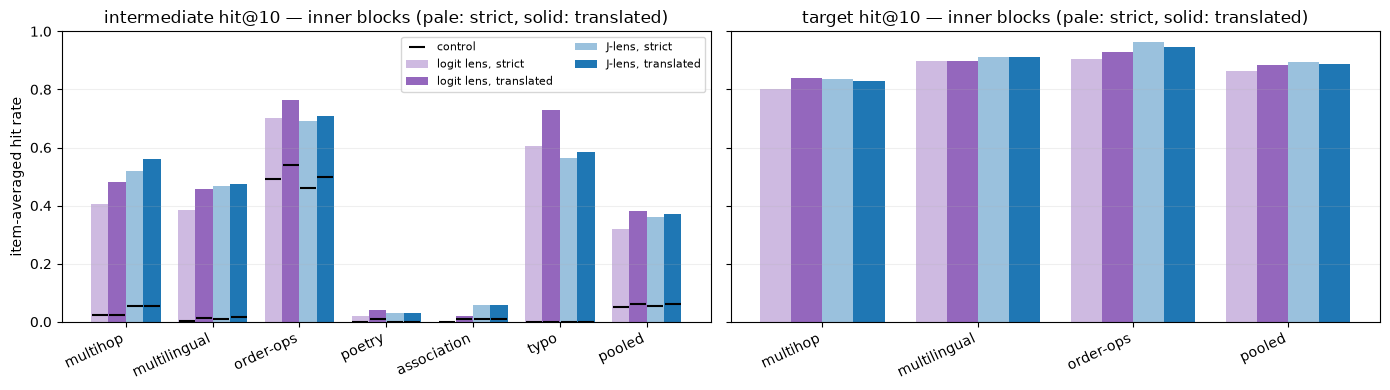

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, kind in zip(axes, ["intermediate", "target"], strict=True):
    tables = {scheme: bench[kind, scheme] for scheme in SCHEMES}
    index = tables["strict"].index
    x = np.arange(len(index))
    offsets = {("logit lens", "strict"): -0.3, ("logit lens", "translated"): -0.1,
               ("J-lens", "strict"): 0.1, ("J-lens", "translated"): 0.3}
    for (lens_name, scheme), offset in offsets.items():
        values = tables[scheme].reindex(index)[lens_name]
        ax.bar(x + offset, values, 0.2, color=COLORS[lens_name], alpha=0.45 if scheme == "strict" else 1.0,
               label=f"{lens_name}, {scheme}")
        if kind == "intermediate":
            control = bench["control", scheme].reindex(index)[lens_name]
            ax.scatter(x + offset, control, marker="_", s=120, color="k", zorder=3,
                       label="control" if (lens_name, scheme) == ("J-lens", "translated") else None)
    ax.set_xticks(x, index, rotation=25, ha="right")
    ax.set(title=f"{kind} hit@{K} — inner blocks (pale: strict, solid: translated)", ylim=(0, 1))
    ax.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("item-averaged hit rate")
axes[0].legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()
plt.close(fig)

## 4. Prompt guard: words already present in the prompt

A word is *in the prompt* when one of its accepted tokens is a prompt token. Translation adds
such cases: in non-Latin multilingual prompts the source word itself (`香蕉` = *banana*) or the
language name is often in the prompt. The paper's intermediates are concepts **absent** from the
input, so the benchmark is repeated without words that are in the prompt under the
translated protocol (dropped from both protocols, to keep the comparison paired).

In [10]:
flags = all_words[all_words["lens"].eq("J-lens")].pivot_table(
    index=["dataset", "item", "kind", "role"], columns="scheme", values="in_prompt", aggfunc="first",
)
print("intermediates in the prompt (count of words):")
display(flags.xs("intermediate", level="kind").groupby("dataset").sum().astype(int))

in_prompt_keys = set(flags[flags["translated"].eq(True)].index)
guarded = all_words[[key not in in_prompt_keys for key in
                     zip(all_words["dataset"], all_words["item"], all_words["kind"], all_words["role"], strict=True)]]
for scheme in SCHEMES:
    wide = scores(scheme, "intermediate", words=guarded)
    show(f"intermediate hit@{K} without in-prompt words — {scheme}",
         compare(wide["logit lens"], wide["J-lens"], "logit lens", "J-lens"))

intermediates in the prompt (count of words):


scheme,strict,translated
dataset,,
association,0,0
multihop,1,1
multilingual,3,14
order-ops,51,56
poetry,0,0
typo,0,0


intermediate hit@10 without in-prompt words — strict


,n_items,logit lens,J-lens,J-lens − logit lens,CI low,CI high
dataset,,,,,,
multihop,83,0.409639,0.524096,0.114458,0.036145,0.198795
multilingual,107,0.384735,0.461059,0.076324,0.043614,0.107477
order-ops,51,0.588235,0.725490,0.137255,0.029412,0.254902
poetry,98,0.020408,0.030612,0.010204,-0.020408,0.051020
association,102,0.000000,0.058824,0.058824,0.019608,0.107843
typo,96,0.604167,0.562500,-0.041667,-0.156250,0.083333
pooled,537,0.307573,0.359094,0.051521,0.021105,0.081941


intermediate hit@10 without in-prompt words — translated


,n_items,logit lens,J-lens,J-lens − logit lens,CI low,CI high
dataset,,,,,,
multihop,83,0.475904,0.566265,0.090361,0.000000,0.186747
multilingual,107,0.448598,0.462617,0.014019,-0.019470,0.045171
order-ops,52,0.721154,0.750000,0.028846,-0.076923,0.134615
poetry,98,0.040816,0.030612,-0.010204,-0.061224,0.030612
association,102,0.019608,0.058824,0.039216,0.000000,0.088235
typo,96,0.729167,0.583333,-0.145833,-0.260417,-0.020833
pooled,538,0.373606,0.372677,-0.000929,-0.032683,0.031599


## 5. Which translated tokens produce the hits

Every inner-block **top-1** readout that is a *translated* (not strict) token of one of the
item's intermediates or its target, with the gloss that made it match. This is the check on
the glossary: each row should be a genuine rendering of the word.

In [11]:
def translated_top1(lens_name):
    table = items[items["scheme"].eq("translated") & items["lens"].eq(lens_name)]
    words = all_words[all_words["scheme"].eq("translated") & all_words["lens"].eq(lens_name)
                      & all_words["kind"].isin(["intermediate", "target"])]
    by_item = {key: group for key, group in words.groupby(["dataset", "item"])}
    rows = []
    for row in table.itertuples():
        group = by_item.get((row.dataset, row.item))
        if group is None:
            continue
        for layer, token_id in enumerate(np.asarray(row.readout_top1_ids)[:-1]):
            for word in group.itertuples():
                if translated.source(word.word, int(token_id), row.dataset == "order-ops") == "translated":
                    rows.append({"dataset": row.dataset, "item": row.item, "layer": layer, "kind": word.kind,
                                 "word": word.word, "token": tokenizer.decode([int(token_id)]),
                                 "gloss": translated.glossary.get(int(token_id), "")})
    return pd.DataFrame(rows, columns=["dataset", "item", "layer", "kind", "word", "token", "gloss"])


top1_hits = {lens_name: translated_top1(lens_name) for lens_name in LENSES}
for lens_name in LENSES:
    frame = top1_hits[lens_name]
    print(f"{lens_name}: {len(frame)} translated top-1 matches in {frame[['dataset', 'item']].drop_duplicates().shape[0]} items")
    display(frame.groupby(["word", "token", "gloss"]).size().rename("layers").sort_values(ascending=False)
            .head(30).to_frame())

logit lens: 547 translated top-1 matches in 148 items


,,,layers
word,token,gloss,
six,六,six,28
night,夜,night,24
16,十六,sixteen,14
right,右,right,14
12,十二,twelve,13
May,五月,may,13
slow,慢,slow,11
squared,平方,square,11
Earth,地球,earth,10


J-lens: 128 translated top-1 matches in 39 items


,,,layers
word,token,gloss,
squared,平方,square,9
黄,yellow,,8
зелен,green,,8
nine,九,nine,8
always,ALWAYS,,7
light,轻,light,6
nhẹ,轻,light,6
16,十六,sixteen,6
15,十五,fifteen,5


**How many Chinese top-1 readouts are the item's concept?** Of all inner-block top-1 tokens
containing CJK characters, the share that is a translated rendering of one of the item's
intermediates or its target. The rest are other words (context, function words, noise).

In [12]:
CJK = re.compile(r"[぀-ヿ㐀-䶿一-鿿豈-﫿가-힯]")
rows = []
for lens_name in LENSES:
    table = items[items["scheme"].eq("translated") & items["lens"].eq(lens_name)]
    hits = top1_hits[lens_name]
    matched = set(zip(hits["dataset"], hits["item"], hits["layer"], strict=True))
    for row in table.itertuples():
        for layer, token in enumerate(row.readout_top1[:-1]):
            if CJK.search(token):
                rows.append({"dataset": row.dataset, "lens": lens_name,
                             "concept": (row.dataset, row.item, layer) in matched})
cjk = pd.DataFrame(rows)
summary = cjk.groupby(["dataset", "lens"])["concept"].agg(cjk_top1="size", is_concept="mean").unstack("lens")
display(summary.style.format(precision=2))

## 6. Per-layer curves, strict vs translated

Fraction of supported intermediates ranked ≤ K at each block (item-averaged); dashed:
strict, solid: translated. The last point is the shared model output.

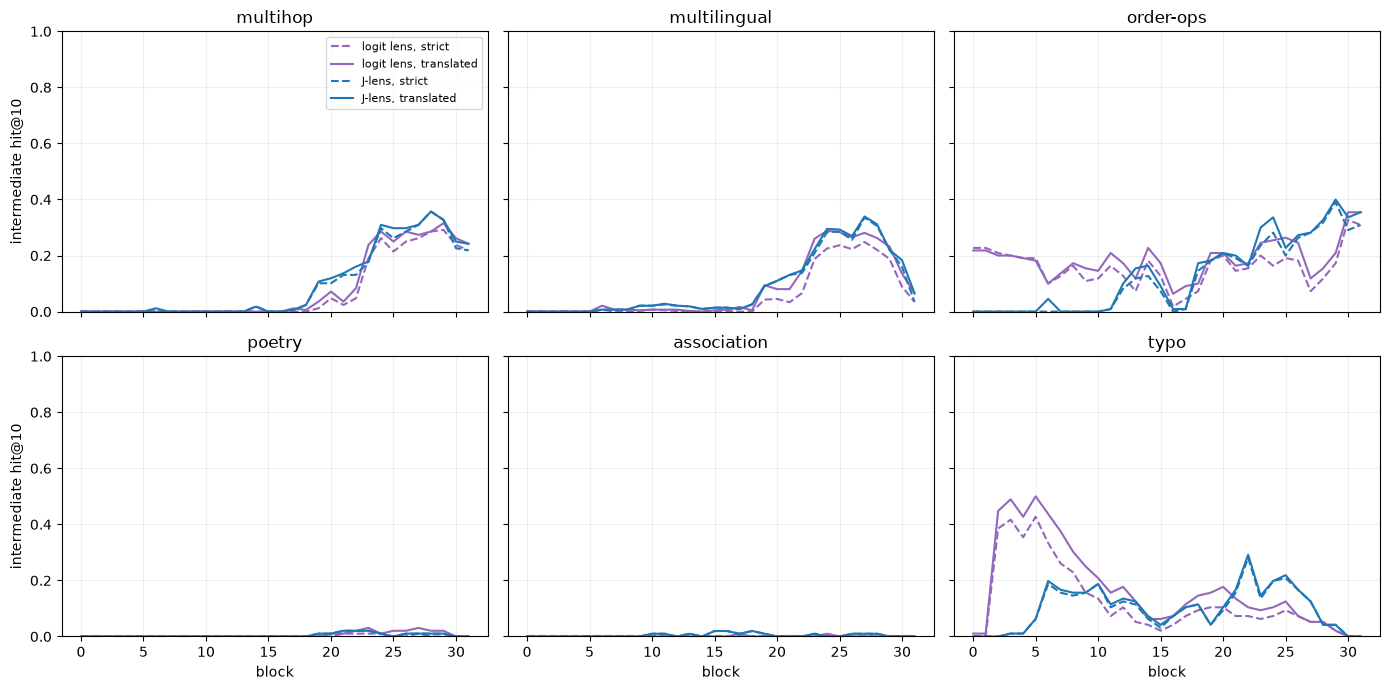

In [13]:
def layer_curve(scheme, dataset, lens_name):
    words = all_words[
        all_words["scheme"].eq(scheme) & all_words["kind"].eq("intermediate")
        & all_words["single_token"].eq(True) & all_words["dataset"].eq(dataset) & all_words["lens"].eq(lens_name)
    ]
    if words.empty:
        return None
    hits = pd.DataFrame(np.stack(words["ranks"]) <= K, index=words.index)
    return hits.join(words["item"]).groupby("item").mean().mean().to_numpy()


fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for ax, dataset in zip(axes.flat, DATASETS, strict=True):
    for lens_name in LENSES:
        for scheme, style in (("strict", "--"), ("translated", "-")):
            curve = layer_curve(scheme, dataset, lens_name)
            if curve is not None:
                ax.plot(curve, style, color=COLORS[lens_name], label=f"{lens_name}, {scheme}")
    ax.set(title=dataset, ylim=(0, 1))
    ax.grid(alpha=0.2)
for ax in axes[-1]:
    ax.set_xlabel("block")
for ax in axes[:, 0]:
    ax.set_ylabel(f"intermediate hit@{K}")
axes[0, 0].legend(fontsize=8)
fig.tight_layout()
plt.show()
plt.close(fig)

## 7. Per-block readouts with glosses

Top-1 token of each lens at every 2nd block, verbatim, with the glossary's English in
parentheses; the same items as the summary notebook plus the order-ops example. `best rank`
compares each word's best inner rank under the two protocols.

In [14]:
def show_item(dataset, item_name):
    rows = items[items["dataset"].eq(dataset) & items["item"].eq(item_name) & items["scheme"].eq("translated")]
    rows = rows.set_index("lens")
    head = rows.iloc[0]
    print(f"[{dataset}] {item_name}: {head['prompt'][-160:]!r}")
    print(f"target={head['target']!r}  model top-1={head['model_top1']!r}  correct (translated)={head['model_correct']}")
    words = all_words[all_words["dataset"].eq(dataset) & all_words["item"].eq(item_name)
                      & all_words["kind"].isin(["intermediate", "target"])]
    words = words.assign(inner_best=words["ranks"].map(lambda r: None if r is None else int(np.asarray(r)[:-1].min())))
    display(words.pivot_table(index=["kind", "word"], columns=["lens", "scheme"], values="inner_best", aggfunc="first"))
    table = pd.DataFrame({name: [show_token(int(t)) for t in rows.loc[name, "readout_top1_ids"]] for name in LENSES})
    table.index.name = "block"
    display(table.iloc[::2].T)


for dataset, item_name in [("multihop", "spider-legs"), ("multilingual", "spanish-opposite-big"),
                           ("multilingual", "chinese-color-banana"), ("order-ops", "parens-add-mult"),
                           ("poetry", "couplet-breath-death"), ("association", "dawn")]:
    show_item(dataset, item_name)

[multihop] spider-legs: 'Fact: The number of legs on the animal that spins webs is '
target='8'  model top-1='8'  correct (translated)=True


lens                J-lens            logit lens           
scheme              strict translated     strict translated
kind         word                                          
intermediate spider      1          1          3          2
target       8           1          1          1          1

block,0,2,4,6,8,10,12,14,16,18,20,22,24,26,28,30
logit lens,' ',' ',' ','\xa0',' ',' ',' ',' ','...',' ___',' legs',' legs',' web',' legs',' eight','8'
J-lens,'.',' –',' ，','number','。\\','。\\','\\n','____','____','____','____',' legs',' spider',' legs',' eight','8'


[multilingual] spanish-opposite-big: 'Lo opuesto de "grande" es "'
target='pequeño'  model top-1='pe'  correct (translated)=False


lens                  J-lens            logit lens           
scheme                strict translated     strict translated
kind         word                                            
intermediate Spanish     775        329       2585       2585
             big         108        108        157         48
             opposite   7112        640        101         32
             small         1          1          1          1
target       pequeño       1          1          1          1

...

lens               J-lens            logit lens           
scheme             strict translated     strict translated
kind         word                                         
intermediate death      1          1         56         14

block,0,2,4,6,8,10,12,14,16,18,20,22,24,26,28,30
logit lens,' ',"""'""",'...','...','一' (one),'(','初次' (first time),'...','...',' ','________________','\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0',' while','While','His','As'
J-lens,'–',' […]','ly','。<','“','“','“','...\\','____','____','____',' Death',' While',' His',' His','As'


[association] dawn: "The first bird started before the sky did, and the cold had that thin quality that wouldn't last another hour."
target=nan  model top-1='\n'  correct (translated)=None


lens              J-lens            logit lens           
scheme            strict translated     strict translated
kind         word                                        
intermediate dawn      6          6        207        207

block,0,2,4,6,8,10,12,14,16,18,20,22,24,26,28,30
logit lens,' ','\n','入' (enter),'寒' (cold),'行' (go),'算' (calculate),'unii','侵' (invade),'uu','纪元' (era),'_fast','uu','揉了揉' (rubbed),'\n',' It',' It'
J-lens,"','",'….','.','\xa0','\xa0','\xa0','\xa0','——',' winter','\xa0','\xa0',' wasn',' It',' Snow',' It',' It'


## Conclusions

* **The J-lens's English-only advantage on Qwen3.5-9B is largely a readout-language effect.** The
  logit lens often surfaces the right concept in Chinese, which strict scoring misses. The J-lens more
  often surfaces it in English: for `"香蕉"的颜色是"` it reads ` yellow` at blocks 22–28 while the logit
  lens reads `黄色`. Credit both and the pooled gap closes (hit@10 tie, AUC slightly favours the logit lens).
* **What survives:** multihop still leans J-lens, significantly by AUC (+0.061 [+0.022, +0.098]), and
  association keeps a borderline J-lens edge near the floor (+0.039 [0.000, +0.088]). The J-lens is not worse at finding concepts
  overall; it is a different readout that happens to be more English-aligned.
* **Typo favours the logit lens** under translation. Its extra hits come at blocks 2–10 (§6), early
  readouts of the corrected word close to the input, where the J-lens is weak.
* **Order-ops depends on the guard.** Many order-ops intermediates are in the prompt through their
  synonyms (`*` for *multiplication*): 51 of 110 strictly, 56 translated. Without them the strict
  J-lens lead is +0.137 [+0.029, +0.255], but translated it shrinks to +0.029 [−0.077, +0.135].
  Order-ops controls are high (0.46–0.54), so its absolute scores say little.
* **The glossary looks reliable where it matters.** The translated top-1 matches in §5 are genuine
  renderings (`六` six, `夜` night, `十六` sixteen, `五月` May, `地球` Earth, `平方` square, `二十` twenty),
  with no obvious false friends among the frequent ones. Its provenance is still unverified, and
  common words get large accepted sets (*small* +66 tokens). The controls bound the chance level that adds.
* **Chinese readouts are mostly not the item's concept.** On association and poetry fewer than 0.5% of
  ~1,200 logit-lens Chinese top-1 tokens were the annotated word: these are context words and noise
  (`揉了揉` rubbed, `纪元` era). Their near-zero scores are genuine misses, not translation misses.

**Limitations.** Whole tokens only, so multi-token translations (`火曜日`, `лёгкий`, `أحمر`) are still
unsupported. Glosses are one English word per token, which loses polysemy (`除` division / remove). The
alias list covers only Chinese operation words. Single readout position, one instruct checkpoint in bf16,
one third-party lens. Held-out Figures 55/56 do not depend on labels; see `qwen35_9b_lens_summary.ipynb`.

**Next.** Score multi-token translations by the rank of their first token conditioned on the lens's
readout, or by sequence probability. Repeat on the base checkpoint, where the readout language may
differ. Test whether the J-lens's English bias comes from the WikiText fitting corpus by fitting on a
mixed-language corpus.